In [10]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from sklearn.metrics import mean_absolute_error, mean_squared_error
from models import *

In [11]:
data= load_data()



/Users/andresilva/Desktop/Séries Temporais/TSF-PROJ/utils.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['log_diff'] = np.log(selected_data['tdiff'])
/Users/andresilva/Desktop/Séries Temporais/TSF-PROJ/utils.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_data['lagged_prec'] = selected_data['prec'].shift(1)
/Users/andresilva/Desktop/Séries Temporais/TSF-PROJ/utils.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

In [12]:
data["t_seasdiff"]= data["tdiff"].diff(12)
data_sd = data.dropna(subset=["t_seasdiff"])

In [13]:
target = "t_seasdiff"

In [14]:
check_stationarity(data_sd[target], regression='c')

ADF Statistic: -7.2188813814276775
p-value: 2.1371308431550362e-10
Stationary
KPSS Statistic: 0.01921813204590542
p-value: 0.1
Stationary


/Users/andresilva/Desktop/Séries Temporais/TSF-PROJ/utils.py:63: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_val = kpss(timeseries, regression=regression, nlags="auto")


In [15]:
cand_res = sarima_candidates_from_acf(
    data_sd['t_seasdiff'],
    m=12,
    max_p=3,
    max_q=3,
    max_P=3,
    max_Q=3,
    max_lag=100
)

candidates = cand_res["candidates"]

for i, (p, d, q, P, D, Q, s) in enumerate(candidates, 1):
    print(f"{i:02d}. SARIMA({p},{d},{q})({P},{D},{Q},{s})")

01. SARIMA(0,0,0)(0,0,0,12)
02. SARIMA(0,0,0)(0,0,1,12)
03. SARIMA(0,0,0)(1,0,0,12)
04. SARIMA(0,0,0)(1,0,1,12)
05. SARIMA(0,0,0)(2,0,0,12)
06. SARIMA(0,0,0)(2,0,1,12)
07. SARIMA(0,0,0)(3,0,0,12)
08. SARIMA(0,0,0)(3,0,1,12)
09. SARIMA(0,0,1)(0,0,0,12)
10. SARIMA(0,0,1)(0,0,1,12)
11. SARIMA(0,0,1)(1,0,0,12)
12. SARIMA(0,0,1)(1,0,1,12)
13. SARIMA(0,0,1)(2,0,0,12)
14. SARIMA(0,0,1)(2,0,1,12)
15. SARIMA(0,0,1)(3,0,0,12)
16. SARIMA(0,0,1)(3,0,1,12)
17. SARIMA(0,0,2)(0,0,0,12)
18. SARIMA(0,0,2)(0,0,1,12)
19. SARIMA(0,0,2)(1,0,0,12)
20. SARIMA(0,0,2)(1,0,1,12)
21. SARIMA(0,0,2)(2,0,0,12)
22. SARIMA(0,0,2)(2,0,1,12)
23. SARIMA(0,0,2)(3,0,0,12)
24. SARIMA(0,0,2)(3,0,1,12)
25. SARIMA(1,0,0)(0,0,0,12)
26. SARIMA(1,0,0)(0,0,1,12)
27. SARIMA(1,0,0)(1,0,0,12)
28. SARIMA(1,0,0)(1,0,1,12)
29. SARIMA(1,0,0)(2,0,0,12)
30. SARIMA(1,0,0)(2,0,1,12)
31. SARIMA(1,0,0)(3,0,0,12)
32. SARIMA(1,0,0)(3,0,1,12)
33. SARIMA(1,0,1)(0,0,0,12)
34. SARIMA(1,0,1)(0,0,1,12)
35. SARIMA(1,0,1)(1,0,0,12)
36. SARIMA(1,0,1)(1,

In [16]:
train_years = 9
h = 12
train_size = train_years * h

best_info, scores_df = select_best_sarima_cv(
    df=data_sd,
    target=target,
    candidates=candidates,
    forecast_window=h,
    train_size=train_size,
    step=h,       # 1 year
    metric="rmse",
)



/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No fr

01. SARIMA(0,0,0)(0,0,0,12) - mean RMSE=1.9297, mean MAE=1.5438


/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No fr

02. SARIMA(0,0,0)(0,0,1,12) - mean RMSE=1.4423, mean MAE=1.1549


/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No fr

...

70. SARIMA(2,0,2)(2,0,1,12) - mean RMSE=1.5634, mean MAE=1.2866


/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No fr

71. SARIMA(2,0,2)(3,0,0,12) - mean RMSE=1.5434, mean MAE=1.2663


/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No fr

72. SARIMA(2,0,2)(3,0,1,12) - mean RMSE=1.5650, mean MAE=1.2843

=== BEST BY ROLLING CV ===
Metric: rmse
Best order:        (0, 0, 2)
Best seasonal:     (0, 0, 1, 12)
Best mean RMSE:    1.4274458383202635
Best mean MAE:     1.136654526169514


/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/andresilva/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


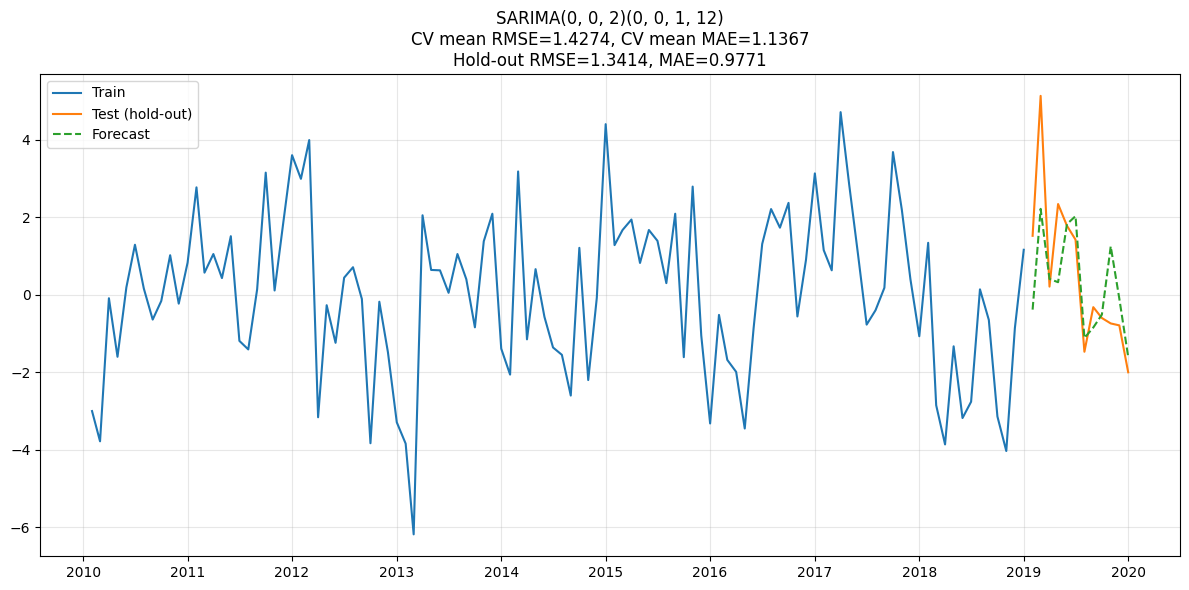

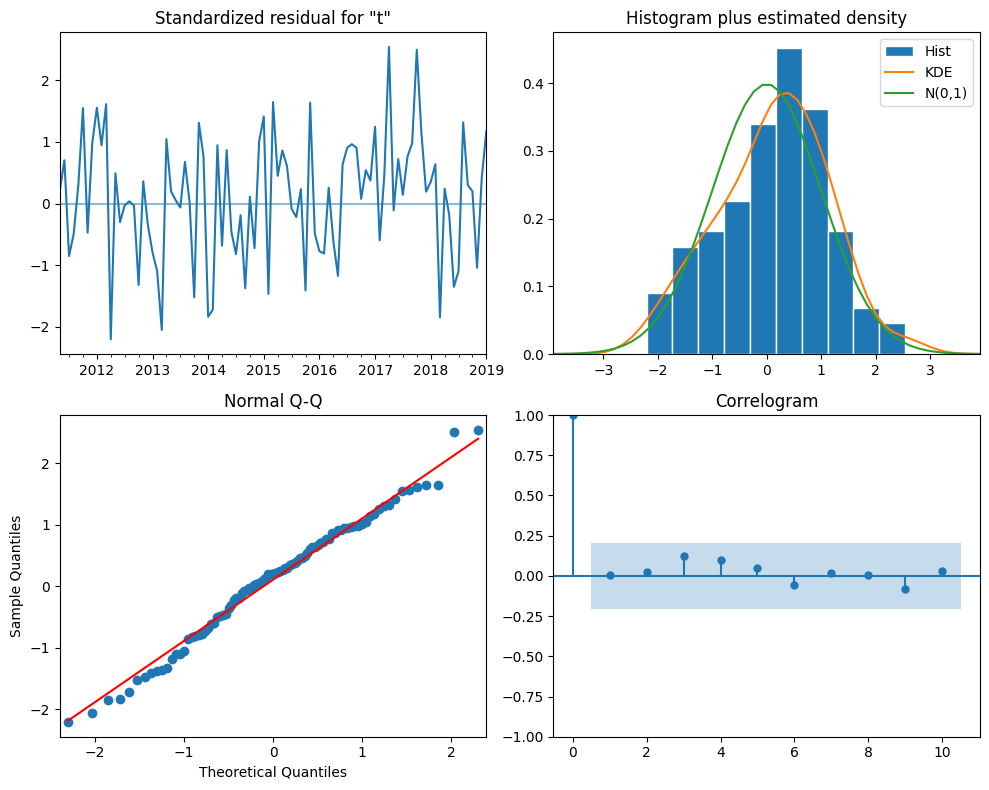

{'results': <statsmodels.tsa.statespace.sarimax.SARIMAXResultsWrapper at 0x345f2d7c0>,
 'forecast': date
 2019-02-01   -0.383326
 2019-03-01    2.215383
 2019-04-01    0.407267
 2019-05-01    0.323334
 2019-06-01    1.822222
 2019-07-01    2.028889
 2019-08-01   -1.115556
 2019-09-01   -0.845556
 2019-10-01   -0.513334
 2019-11-01    1.247777
 2019-12-01   -0.100001
 2020-01-01   -1.602223
 Name: predicted_mean, dtype: float64,
 'test': date
 2019-02-01    1.52
 2019-03-01    5.13
 2019-04-01    0.21
 2019-05-01    2.34
 2019-06-01    1.78
 2019-07-01    1.42
 2019-08-01   -1.47
 2019-09-01   -0.32
 2019-10-01   -0.60
 2019-11-01   -0.74
 2019-12-01   -0.79
 2020-01-01   -2.00
 Name: t_seasdiff, dtype: float64,
 'rmse': 1.3413600968258446,
 'mae': 0.977100564762861}

In [17]:
plot_best_sarimax_final(
    df=data_sd,
    target=target,
    best_info=best_info,
    forecast_window=h,
    train_size=train_size,  # or None to use all data before last 12 months
    exog=None,              # or list of exogenous columns
)